In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scoring

# Parameter Sweeps


In order to determine what distance threshold to use for hierarchical clustering, a parameter sweep was performed. A different parameter sweep was performed for each zone, as defined by "Milani et al. (2014). Asteroid families classification: Exploiting very large datasets." The zones are split by semi-major axis and inclination, and are defined as follows:

| Zone    | Sine of Inclination | Semimajor Axis Range |
|---------|---------------------|----------------------|
| 1       | all                 | 1.600 - 2.000        |
| 2 low   | < 0.3               | 2.000 - 2.500        |
| 2 high  | > 0.3               | 2.000 - 2.500        |
| 3 low   | < 0.3               | 2.500 - 2.825        |
| 3 high  | > 0.3               | 2.500 - 2.825        |
| 4 low   | < 0.3               | 2.825 - 3.278        |
| 4 high  | > 0.3               | 2.825 - 3.278        |
| 5       | all                 | 3.278 - 3.700        |
| 6       | all                 | 3.700 - 4.000        |

The efficacy of each distance threshold was evaluated by how well each resulting cluster captured its "main family," the family that has the most members in the cluster. The following metrics were used to evaluate the quality of the clusters:
1. **Completeness**: The percentage of the main family that is captured by the cluster. A cluster is considered **complete** if it captures at least 95% of its main family.
2. **Purity**: The percentage of the cluster that belongs to the main family. A cluster is considered **pure** if at least 95% of its members belong to the main family.

The plots below show the following metrics for each distance threshold:
1. The number of **complete** clusters found
2. The number of **complete and pure** clusters found
3. The average **purity** of **complete** clusters

Distance thresholds that yield a high number of complete clusters, while maintaining a high average purity, were chosen as optimal thresholds for hierarchical clustering.

## Zone 1

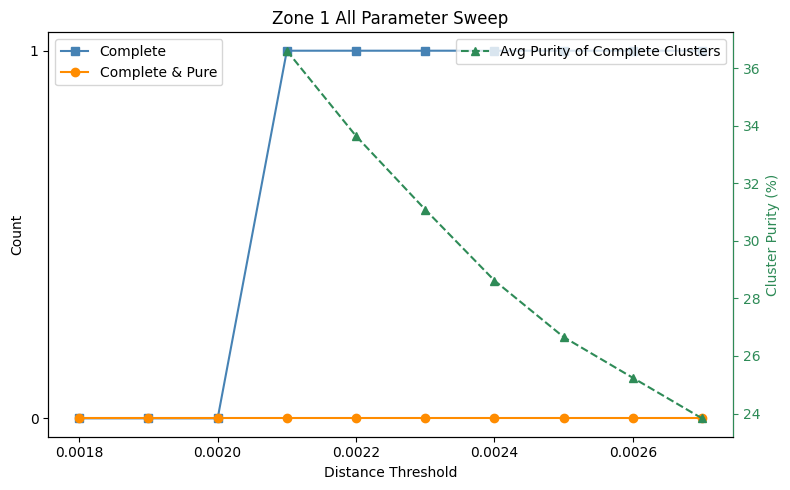

In [16]:
z1_sweep = scoring.param_sweep(
    zone=1, inc="all", min_dist=0.0018, max_dist=0.0028, step=0.0001
)

0.0021 was chosen for Zone 1.

Zone 1 only contains one family, so the lowest distance threshold that allows that family to become complete was chosen, as higher distance thresholds only decrease purity.

## Zone 2

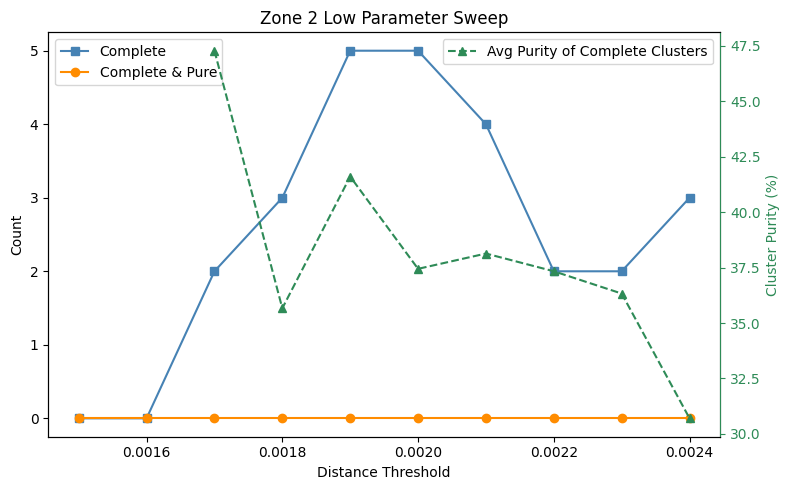

In [4]:
z2_sweep = scoring.param_sweep(
    zone=2, inc="low", min_dist=0.0015, max_dist=0.0025, step=0.0001
)

0.0019 was chosen for Zone 2 Low.

Zone 2 Low jumps from 3 to 5 complete clusters going from 0.0018 to 0.0019. From then on, the number of complete clusters and average purity of complete clusters only decreases.

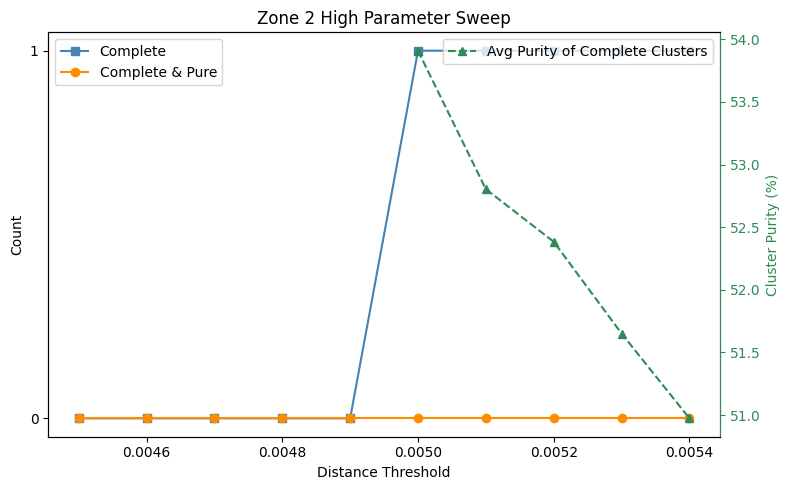

In [15]:
z2_hi_sweep = scoring.param_sweep(
    zone=2, inc="high", min_dist=0.0045, max_dist=0.0055, step=0.0001
)

0.0050 was chosen for Zone 2 High.

Similar to Zone 1, Zone 2 High only contains one family, so the lowest distance threshold that allows that family to become complete was chosen.

## Zone 3

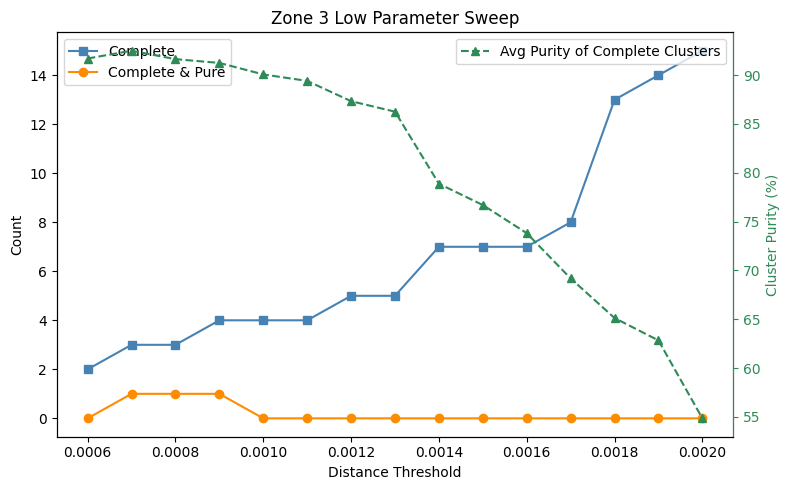

In [7]:
z3_sweep = scoring.param_sweep(
    zone=3, inc="low", min_dist=0.0006, max_dist=0.0020, step=0.0001
)

0.0014 was chosen for Zone 3 Low.

While 0.0013 yields a higher average purity for complete cluster, the extra two complete clusters found at 0.0014 were prioritized over the higher purity. Additionally, while a complete and pure cluster is found from 0.0007-0.0009, the larger number of complete clusters was prioritized.

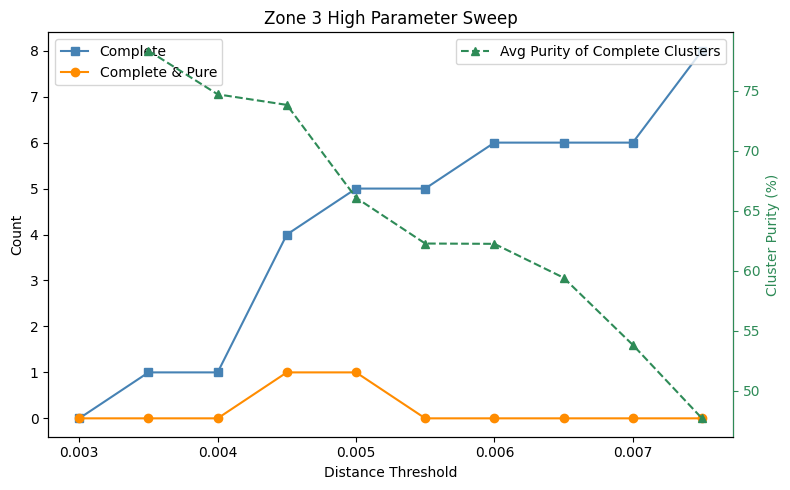

In [10]:
z3_hi_sweep = scoring.param_sweep(
    zone=3, inc="high", min_dist=0.003, max_dist=0.008, step=0.0005
)

0.0045 was chosen for Zone 3 High.

Three additional complete clusters are found going from 0.0040 to 0.0045, with a negligible decrease in average purity. Additionally, one of these complete families is both complete and pure. While more complete clusters are found at higher distance thresholds, the average purity significantly decreases. 0.0045 was chosen as nice balance between the number of complete clusters and average purity.

## Zone 4

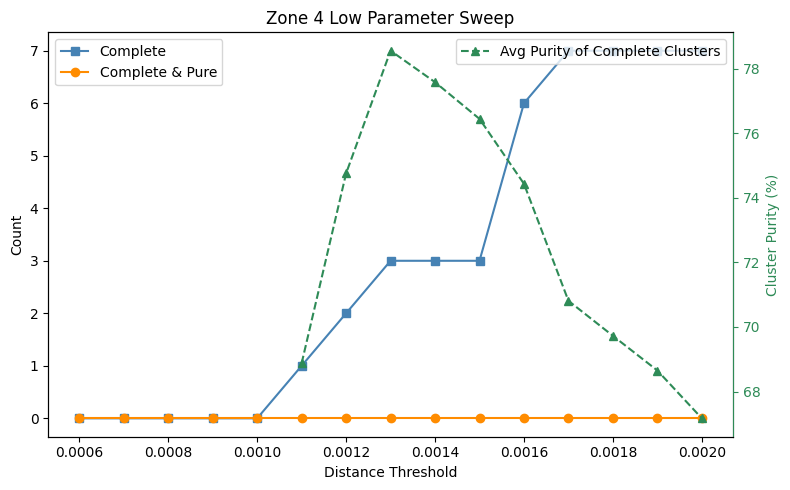

In [11]:
z4_sweep = scoring.param_sweep(
    zone=4, inc="low", min_dist=0.0006, max_dist=0.0020, step=0.0001
)

0.0016 was chosen for Zone 4 Low.

Going from 0.0015 to 0.0016 adds three more complete clusters, with a negligible decrease in average purity. At high distance thresholds purity decreases more significantly.



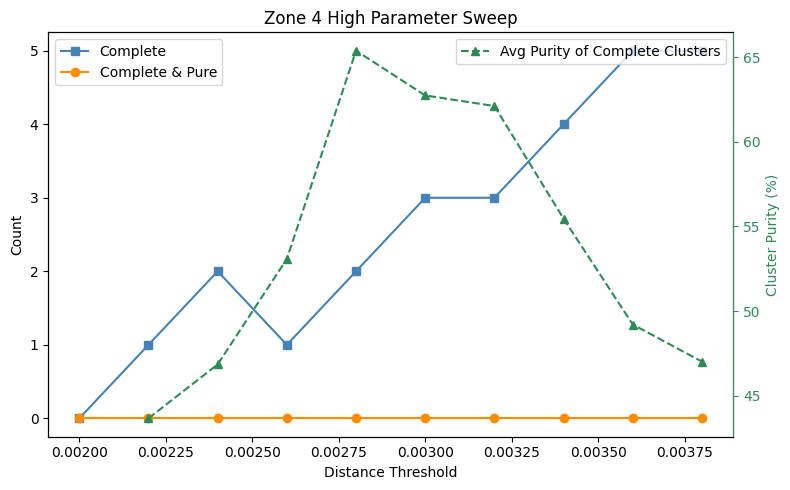

In [12]:
z4_hi_sweep = scoring.param_sweep(
    zone=4, inc="high", min_dist=0.002, max_dist=0.004, step=0.0002
)

0.0030 was chosen for Zone 4 High.

At 0.0030, a decent number of complete clusters are found while maintaining a high average purity. At higher distance thresholds, while more complete clusters are found, the average purity decreases.

## Zone 5

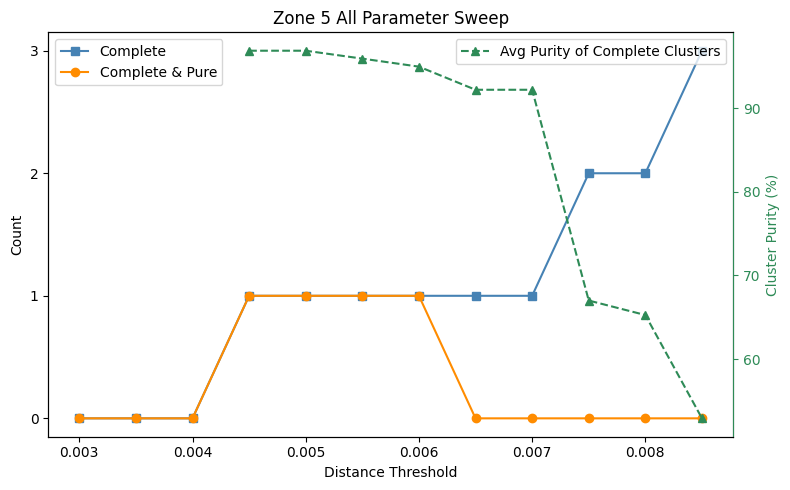

In [14]:
z5_sweep = scoring.param_sweep(
    zone=5, inc="all", min_dist=0.003, max_dist=0.009, step=0.0005
)

0.0045 was chosen for zone 4.

At 0.0045, a complete and pure cluster is found. Another complete cluster is not found until 0.0075, which drastically decreases average purity.

## Zone 6

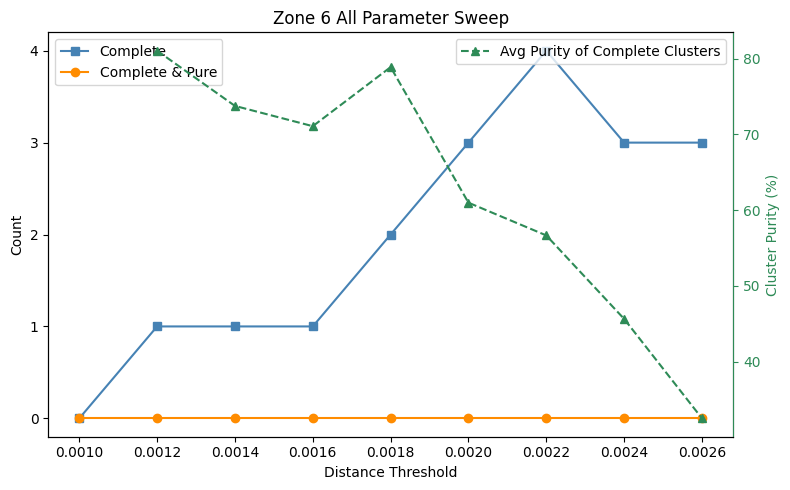

In [19]:
z6_sweep = scoring.param_sweep(
    zone=6, inc="all", min_dist=0.001, max_dist=0.0028, step=0.0002
)

0.0018 was chosen for Zone 6.

The additional cluster found at 0.0018 actually shows an increase in average purity. After that, additional complete clusters only decrease average purity.

## Summary

From the parameter sweeps, the following distance thresholds were chosen:
| Zone    | Distance Threshold |
|---------|--------------------|
| 1       | 0.0021             |
| 2 low   | 0.0019             |
| 2 high  | 0.0050             |
| 3 low   | 0.0014             |
| 3 high  | 0.0045             |
| 4 low   | 0.0016             |
| 4 high  | 0.0030             |
| 5       | 0.0045             |
| 6       | 0.0018             |

A higher distance threshold was chosen for high inclination zones as well as zone 5, as asteroids in these zones are more sparse. This matches the findings of Milani et al. (2014).

Complete clustering is explored in `main.ipynb`.